# 🌱 PINN v3 — Root-Zone Soil Moisture *(Real-Time Dashboard)*
**Based on:** Chuphal et al. (2026) — *Scientific Data 13:560* | IIT Gandhinagar

### Changes from v2 → v3 (this notebook)
| Fix | v2 Bug | v3 Fix |
|---|---|---|
| **Temporal split** | Sorted by lat/lon → spatial holdout, not temporal | Sort by time first → true chronological 70/15/15 |
| **Fourier encoder scale** | PHYS_COLS unscaled (0–50mm) mixed with standardised features | PHYS_COLS excluded from Fourier encoder; bypass as direct features |
| **T_DAYS** | Hardcoded 3650 (assumed 10 yrs) → wrong PDE chain rule | Computed dynamically from actual data time range |
| **Physics weight Phase 2** | lw_phys=0.5 → over-constrained, systematic bias | lw_phys=0.15 |
| **gwet loss** | lw_gwet=0.1 toward SM_root (≠ SMAP target) → hidden bias | lw_gwet=0.01 (near-zero; decoupled from data target) |
| **Phase 3 physics init** | log_lw_phys=0 → effective weight 1.0, dominated physics | Initialised to 2.3 → effective weight ≈ 0.1 |
| **Bias correction** | No post-processing | Additive val-set correction applied at inference |
| **Checkpoint metric** | Val RMSE ✓ | Val RMSE ✓ (unchanged) |

In [19]:
import os, math, time, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              mean_absolute_error, confusion_matrix)
from scipy.stats import pearsonr, norm as sp_norm
from tqdm.notebook import tqdm, trange

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display

NAVY   = '#1B3A6B'; TEAL   = '#0D7680'; GREEN  = '#1A6B3C'
ORANGE = '#C45E00'; PURPLE = '#5B2D8E'; RED    = '#C0392B'; GOLD = '#D4AC0D'

plt.rcParams.update({
    'figure.facecolor':  'white', 'axes.facecolor': '#F8F9FA',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'font.size': 9,
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPS    = 1e-8
print(f'✓ Imports OK  |  Device: {DEVICE}')

✓ Imports OK  |  Device: cuda


## ⚙️ Configuration

In [20]:
CFG = dict(
    csv_path        = 'pinn_data_nagpur/train.csv',

    # Architecture
    fourier_dim     = 128,
    fourier_sigma   = 1.0,
    hidden_dim      = 512,
    n_res_blocks    = 6,
    dropout_p       = 0.10,

    # Training
    QUICK           = True,
    phase1_end      = 30,
    phase2_end      = 90,
    phase3_end      = 210,
    phase4_end      = 250,
    total_epochs    = 250,

    # Optimiser
    lr              = 1e-3,
    lr_factor       = 0.5,
    lr_patience     = 3,
    lr_cooldown     = 1,
    lr_min          = 1e-6,
    lr_threshold    = 1e-4,
    batch_size      = 512,
    grad_clip       = 1.0,

    # FIX v3: lw_phys 0.5→0.15 (Phase 2 over-constrained bias source)
    # FIX v3: lw_gwet 0.1→0.01 (SM_root_power_frac ≠ SMAP target → hidden bias)
    lw_data=1.0, lw_phys=0.15, lw_et=0.25, lw_gwet=0.01,
    Zr=1.0, seed=42,

    # Dashboard
    log_every_batch = 20,
    log_every_epoch = 4,
)

if not CFG['QUICK']:
    CFG.update(phase1_end=2000, phase2_end=7000,
               phase3_end=25000, phase4_end=28000, total_epochs=28000)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
print(f"✓ Config  |  {CFG['total_epochs']} epochs  "
      f"({'QUICK' if CFG['QUICK'] else 'FULL'})")
print(f"  lw_phys={CFG['lw_phys']} (was 0.5)  |  lw_gwet={CFG['lw_gwet']} (was 0.1)")

✓ Config  |  250 epochs  (QUICK)
  lw_phys=0.15 (was 0.5)  |  lw_gwet=0.01 (was 0.1)


## 📐 Features

In [21]:
BASE_FEATURES = [
    'sand','clay','silt','bdod','soc','cec','pH',
    'theta_s','theta_fc','theta_wp','Ks_m_per_day',
    'lat','lon','lat_sin','lat_cos','lon_sin','lon_cos',
    'year_norm','doy_sin','doy_cos',
    'TEMP_mean_power_C','TEMP_max_power_C','TEMP_min_power_C',
    'TEMP_dewpoint_power_C','HUM_RH_power_pct',
    'PRECIP_rain_power_mm','WIND_mean_2m_power_ms',
    'RAD_shortwave_power_kWhm2','ET_actual_power_mm',
    'SM_top_power_frac','SM_root_power_frac',
    'ET_p_penman_mm','P_7day_mm','VPD_kPa',
    'Aridity_Index','beta_stress','T_range_C',
    'agro_zone','soil_texture_class',
]
LAG_FEATURES  = ['SM_root_lag1','SM_root_lag3','SM_root_lag7']
TIME_FEATURE  = ['t_raw']

FEATURE_NAMES = BASE_FEATURES + LAG_FEATURES + TIME_FEATURE
IDX           = {n: i for i, n in enumerate(FEATURE_NAMES)}
TARGET        = 'SMAP_RZSM_m3m3'

CATEGORICAL   = {'agro_zone', 'soil_texture_class'}

PHYS_COLS     = ['theta_wp','theta_fc','theta_s','ET_p_penman_mm',
                 'ET_actual_power_mm','SM_root_power_frac','PRECIP_rain_power_mm']

# FIX v3: Exclude PHYS_COLS from Fourier encoder.
# v2 bug: PHYS_COLS were unscaled (mm/day, m³/m³) while all others were
# StandardScaler-normalised. Mixed scales corrupt the random Fourier projection.
# Fix: Fourier encoder only sees properly-scaled features. PHYS_COLS pass
# through the encoder as raw concatenated inputs (x already contains them).
PHYS_SET      = set(PHYS_COLS)
FOURIER_COLS  = [i for i, n in enumerate(FEATURE_NAMES)
                 if n not in CATEGORICAL and n not in PHYS_SET]

print(f'✓ {len(FEATURE_NAMES)} features total')
print(f'  Fourier-encoded (scaled): {len(FOURIER_COLS)} features  (was {len([i for i,n in enumerate(FEATURE_NAMES) if n not in CATEGORICAL])})')
print(f'  PHYS_COLS bypass Fourier: {PHYS_COLS}')
print(f'  Lag features: {LAG_FEATURES}')
print(f'  Target: {TARGET}')

✓ 43 features total
  Fourier-encoded (scaled): 34 features  (was 41)
  PHYS_COLS bypass Fourier: ['theta_wp', 'theta_fc', 'theta_s', 'ET_p_penman_mm', 'ET_actual_power_mm', 'SM_root_power_frac', 'PRECIP_rain_power_mm']
  Lag features: ['SM_root_lag1', 'SM_root_lag3', 'SM_root_lag7']
  Target: SMAP_RZSM_m3m3


## 🔧 GPU Diagnostics

In [22]:
if torch.cuda.is_available():
    print(f'✓ CUDA: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    print('  TF32 enabled')
else:
    print('✗ CUDA not available — CPU mode')
print('✓ GPU diagnostics complete')

✓ CUDA: NVIDIA GeForce RTX 4050 Laptop GPU
  VRAM: 6.4 GB
  TF32 enabled
✓ GPU diagnostics complete


## 📂 Data Loading, Lag Engineering & Temporal Split

In [ ]:
df_raw = pd.read_csv(CFG['csv_path'])
print(f'Raw: {len(df_raw):,} rows × {len(df_raw.columns)} cols')

# ── Step 1: Determine actual target column ────────────────────────────────
# SMAP_RZSM_m3m3 may be all NaN; fall back to theta_RZSM_m3m3 if needed
actual_target = TARGET
if TARGET not in df_raw.columns or df_raw[TARGET].isna().all():
    if 'theta_RZSM_m3m3' in df_raw.columns and not df_raw['theta_RZSM_m3m3'].isna().all():
        actual_target = 'theta_RZSM_m3m3'
        print(f'⚠ {TARGET} is all NaN; switching to {actual_target}')
    else:
        raise ValueError(f'No valid target found. {TARGET}: all NaN, theta_RZSM_m3m3: all NaN or missing.')

print(f'Target NaN: {df_raw[actual_target].isna().sum():,} ({df_raw[actual_target].isna().mean()*100:.1f}%)')

# ── Step 2: Basic preprocessing ──────────────────────────────────────────
def preprocess_base(df, target_col):
    df = df.dropna(subset=[target_col]).reset_index(drop=True)
    if len(df) == 0:
        raise ValueError(f'All rows dropped after filtering for {target_col}. Check data integrity.')
    for col in ['agro_zone','soil_texture_class']:
        if col in df.columns:
            df[col] = pd.Categorical(df[col]).codes.astype(np.float32)
    return df

df_clean = preprocess_base(df_raw, actual_target)
print(f'After dropna: {len(df_clean):,} rows')

# ── Step 3: FIX v3 — Sort by TIME first, then location ───────────────────
if 'year' in df_clean.columns and 'doy' in df_clean.columns:
    df_clean['_t_sort'] = df_clean['year'].astype(float) * 365 + df_clean['doy'].astype(float)
    print('  ✓ Time sort: using actual year + doy columns')
elif 'year_norm' in df_clean.columns:
    _doy = (np.arctan2(df_clean.get('doy_sin', pd.Series(np.zeros(len(df_clean)))),
                       df_clean.get('doy_cos', pd.Series(np.ones(len(df_clean)))))
            / (2 * np.pi) * 365) % 365
    df_clean['_t_sort'] = df_clean['year_norm'].astype(float) * 10000 + _doy
    print('  ✓ Time sort: reconstructed from year_norm + doy_sin/cos')
else:
    df_clean['_t_sort'] = np.arange(len(df_clean), dtype=np.float32)
    print('  ⚠ No time columns found — using row order')

sort_cols_v3 = ['_t_sort', 'lat', 'lon'] if 'lat' in df_clean.columns else ['_t_sort']
df_clean = df_clean.sort_values(sort_cols_v3).reset_index(drop=True)

t_min_days = df_clean['_t_sort'].min()
t_max_days = df_clean['_t_sort'].max()
print(f'  Time range: {t_min_days:.0f} → {t_max_days:.0f}')

# ── Step 4: Lag features ─────────────────────────────────────────────────
for lag in [1, 3, 7]:
    col = f'SM_root_lag{lag}'
    df_clean[col] = (df_clean.groupby(['lat','lon'])['SM_root_power_frac']
                             .shift(lag)
                             .fillna(df_clean['SM_root_power_frac']))
    print(f'  ✓ {col}: {df_clean[col].isna().sum()} NaN')

# ── Step 5: FIX v3 — Dynamic T_DAYS ──────────────────────────────────────
if 'year' in df_clean.columns and 'doy' in df_clean.columns:
    t_raw_days = df_clean['year'].values * 365. + df_clean['doy'].values
else:
    _doy_approx = (np.arctan2(df_clean['doy_sin'].values,
                               df_clean['doy_cos'].values) / (2*np.pi) * 365) % 365
    t_raw_days = df_clean['year_norm'].values * 3650. + _doy_approx

if len(t_raw_days) == 0:
    raise ValueError('t_raw_days is empty; check data after sorting.')

T_DAYS = float(t_raw_days.max() - t_raw_days.min())
if T_DAYS <= 0:
    T_DAYS = 3650.
    print(f'  ⚠ T_DAYS computed as ≤0; using fallback 3650 days')
else:
    print(f'  ✓ T_DAYS (dynamic): {T_DAYS:.0f} days')

t_raw  = (t_raw_days - t_raw_days.min()) / (T_DAYS + EPS)
df_clean['t_raw'] = t_raw.astype(np.float32)
print(f'  ✓ t_raw: [{t_raw.min():.3f}, {t_raw.max():.3f}]')

# ── Step 6: Build feature matrix ─────────────────────────────────────────
X_all = np.zeros((len(df_clean), len(FEATURE_NAMES)), dtype=np.float32)
for col in FEATURE_NAMES:
    if col in df_clean.columns:
        X_all[:, IDX[col]] = df_clean[col].fillna(0).values.astype(np.float32)
y_all = df_clean[actual_target].values.astype(np.float32)

# ── Step 7: Temporal split ───────────────────────────────────────────────
N = len(X_all)
te_end   = N
te_start = int(N * 0.85)
vl_start = int(N * 0.70)
vl_end   = te_start

tr_idx = np.arange(0, vl_start)
vl_idx = np.arange(vl_start, vl_end)
te_idx = np.arange(te_start, te_end)

X_tr, y_tr = X_all[tr_idx], y_all[tr_idx]
X_vl, y_vl = X_all[vl_idx], y_all[vl_idx]
X_te, y_te = X_all[te_idx], y_all[te_idx]

t_sort_vals = df_clean['_t_sort'].values
print(f'  Train time:  {t_sort_vals[tr_idx[0]]:.1f} → {t_sort_vals[tr_idx[-1]]:.1f}')
print(f'  Val time:    {t_sort_vals[vl_idx[0]]:.1f} → {t_sort_vals[vl_idx[-1]]:.1f}')
print(f'  Test time:   {t_sort_vals[te_idx[0]]:.1f} → {t_sort_vals[te_idx[-1]]:.1f}')

# ── Step 8: Scale — fit on train ONLY ────────────────────────────────────
scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr).astype(np.float32)
X_vl_s  = scaler.transform(X_vl).astype(np.float32)
X_te_s  = scaler.transform(X_te).astype(np.float32)

for col in PHYS_COLS:
    X_tr_s[:, IDX[col]] = X_tr[:, IDX[col]]
    X_vl_s[:, IDX[col]] = X_vl[:, IDX[col]]
    X_te_s[:, IDX[col]] = X_te[:, IDX[col]]

# ── Step 9: DataLoaders ──────────────────────────────────────────────────
def make_loader(X, y, bs, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      pin_memory=(DEVICE=='cuda'), num_workers=0)

tr_loader = make_loader(X_tr_s, y_tr, CFG['batch_size'], True)
vl_loader = make_loader(X_vl_s, y_vl, CFG['batch_size'], False)
te_loader = make_loader(X_te_s, y_te, CFG['batch_size'], False)

print(f'\nTrain {len(y_tr):,}  |  Val {len(y_vl):,}  |  Test {len(y_te):,}')
print(f'Batches per epoch: {len(tr_loader)}')
print(f'Target column used: {actual_target}')
print('Split: TRUE TEMPORAL (time-sorted, chronological 70/15/15)')

# Update global TARGET for consistency in later cells
TARGET = actual_target


## ⚗️ Physics (Section 6)

In [ ]:
def _g(X, key):
    return X[:, IDX[key]].unsqueeze(1)

def beta_fn(theta, wp, fc):
    return ((theta - wp) / (fc - wp).clamp(min=EPS)).clamp(0., 1.)

def surface_runoff(theta, fc, Zr=1.0):
    return torch.relu(theta - fc) * Zr

def subsurface_runoff(theta, ts, Zr=1.0, tau=30.):
    return (theta / ts.clamp(min=EPS)) * (Zr / tau)

def physics_residual(model, X, t_col):
    """
    FIX v3: Uses T_DAYS computed dynamically from actual data range.
    v2 hardcoded T_DAYS=3650 — wrong chain-rule scale if dataset ≠ 10 yrs.
    """
    t = X[:, t_col].unsqueeze(1).detach().requires_grad_(True)
    if t_col == 0:
        Xc = torch.cat([t, X[:, 1:]], dim=1)
    elif t_col == X.shape[1] - 1:
        Xc = torch.cat([X[:, :-1], t], dim=1)
    else:
        Xc = torch.cat([X[:, :t_col].detach(), t, X[:, t_col+1:].detach()], dim=1)

    th = model(Xc)
    grad_t = torch.autograd.grad(th, t, grad_outputs=torch.ones_like(th),
                                  create_graph=True, retain_graph=True)[0]

    # FIX v3: T_DAYS is now a module-level variable set from actual data
    dth_dt = grad_t * T_DAYS   # chain rule: correct physical units m³/m³/day

    wp   = _g(Xc, 'theta_wp'); fc  = _g(Xc, 'theta_fc')
    ts   = _g(Xc, 'theta_s');  ET_p = _g(Xc, 'ET_p_penman_mm') / 1000.
    P    = _g(Xc, 'PRECIP_rain_power_mm') / 1000.
    ET_a = beta_fn(th, wp, fc) * ET_p
    R_s  = surface_runoff(th, fc, CFG['Zr'])
    R_b  = subsurface_runoff(th, ts, CFG['Zr'])
    return ((dth_dt - (P - ET_a - R_s - R_b) / CFG['Zr']) ** 2).mean()

print('✓ Physics helpers ready')
print(f'  PDE time variable: t_raw (IDX = {IDX["t_raw"]})')
print(f'  T_DAYS (dynamic): {T_DAYS:.0f} days  (was hardcoded 3650)')

✓ Physics helpers ready
  PDE time variable: t_raw (IDX = 42)
  T_DAYS (dynamic): 4014 days  (was hardcoded 3650)


## 🧠 PINN Architecture v3

In [ ]:
class FourierEncoder(nn.Module):
    """
    FIX v3: Input dim is now len(FOURIER_COLS), which excludes PHYS_COLS.
    v2 bug: PHYS_COLS (mm/day, unscaled) were mixed with standardised features
    in the same random projection → high-magnitude features dominated the
    Fourier space and degraded encoding quality for all other features.
    """
    def __init__(self, in_dim, fdim, sigma):
        super().__init__()
        self.register_buffer('B', torch.randn(in_dim, fdim // 2) * sigma)
    def forward(self, x):
        p = x @ self.B
        return torch.cat([torch.sin(p), torch.cos(p)], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, d, dropout_p=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, d), nn.SiLU(),
            nn.Dropout(dropout_p),
            nn.Linear(d, d),
        )
        self.act = nn.SiLU()
    def forward(self, x):
        return self.act(x + self.net(x))

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        nf   = len(FEATURE_NAMES)
        fd   = CFG['fourier_dim']
        hd   = CFG['hidden_dim']
        nfc  = len(FOURIER_COLS)      # FIX v3: now excludes PHYS_COLS
        dp   = CFG['dropout_p']

        self.fourier    = FourierEncoder(nfc, fd, CFG['fourier_sigma'])
        self.encoder    = nn.Sequential(nn.Linear(fd + nf, hd), nn.SiLU())
        self.res_blocks = nn.Sequential(
            *[ResBlock(hd, dp) for _ in range(CFG['n_res_blocks'])]
        )
        self.decoder    = nn.Sequential(nn.Linear(hd, 64), nn.SiLU(), nn.Linear(64, 1))

        # FIX v3: log_lw_phys initialised to ln(10) ≈ 2.3 so that the
        # effective physics weight = exp(-2.3) ≈ 0.1 at Phase 3 start.
        # v2 initialised all to 0 → effective weight 1.0 → physics dominated.
        self.register_parameter('log_lw_phys', nn.Parameter(torch.tensor([2.3])))
        for nm in ('data', 'et', 'gwet'):
            self.register_parameter(f'log_lw_{nm}', nn.Parameter(torch.zeros(1)))

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        # FIX v3: Fourier encoder only sees properly-scaled continuous features
        ff  = self.fourier(x[:, FOURIER_COLS])
        h   = self.encoder(torch.cat([ff, x], dim=-1))
        raw = self.decoder(self.res_blocks(h))
        wp  = x[:, IDX['theta_wp']].unsqueeze(1).clamp(min=0.01)
        ts  = x[:, IDX['theta_s']].unsqueeze(1).clamp(min=wp + 0.01)
        return wp + (ts - wp) * torch.sigmoid(raw)

    def aw(self, nm):
        lw = getattr(self, f'log_lw_{nm}')
        return torch.exp(-lw), lw

model    = PINN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✓ PINN v3  |  {n_params:,} params  |  Device: {DEVICE}')
print(f'  Fourier input dim: {len(FOURIER_COLS)} (was {len([i for i,n in enumerate(FEATURE_NAMES) if n not in CATEGORICAL])})')
print(f'  log_lw_phys init: 2.3 → effective weight ≈ 0.10  (was 0 → 1.0)')
print(f'  ResBlocks: {CFG["n_res_blocks"]} × SiLU')
print(f'  Output: hard-bounded per sample to [θ_wp, θ_s]')

✓ PINN v3  |  3,272,837 params  |  Device: cuda
  Fourier input dim: 34 (was 41)
  log_lw_phys init: 2.3 → effective weight ≈ 0.10  (was 0 → 1.0)
  ResBlocks: 6 × SiLU
  Output: hard-bounded per sample to [θ_wp, θ_s]


## ✅ Pre-Training Checklist

In [ ]:
print('🔍 Pre-Training Checklist\n' + '─'*60)
print(f'  Device:              {DEVICE}')
print(f'  Features total:      {len(FEATURE_NAMES)}')
print(f'  Fourier-encoded:     {len(FOURIER_COLS)}  (excl. PHYS_COLS)')
print(f'  Train samples:       {len(y_tr):,}  ({len(tr_loader)} batches × bs={CFG["batch_size"]})')
print(f'  Val / Test:          {len(y_vl):,} / {len(y_te):,}')
print(f'  Split:               TRUE TEMPORAL (chronological 70/15/15)')
print(f'  T_DAYS (dynamic):    {T_DAYS:.0f} days')
print(f'  lw_phys Phase 2:     {CFG["lw_phys"]}  (was 0.5)')
print(f'  lw_gwet:             {CFG["lw_gwet"]}  (was 0.1)')
print(f'  log_lw_phys init:    2.3 → eff. weight ≈ 0.10  (was 1.0)')
print(f'  Model params:        {n_params:,}')
print(f'  AMP:                 {DEVICE == "cuda"}')
if DEVICE == 'cuda':
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM total:          {mem:.1f} GB')
print('─'*60)
print('✅ Ready — run Dashboard cell then Training cell')

🔍 Pre-Training Checklist
────────────────────────────────────────────────────────────
  Device:              cuda
  Features total:      43
  Fourier-encoded:     34  (excl. PHYS_COLS)
  Train samples:       719,724  (1406 batches × bs=512)
  Val / Test:          154,227 / 154,227
  Split:               TRUE TEMPORAL (chronological 70/15/15)
  T_DAYS (dynamic):    4014 days
  lw_phys Phase 2:     0.15  (was 0.5)
  lw_gwet:             0.01  (was 0.1)
  log_lw_phys init:    2.3 → eff. weight ≈ 0.10  (was 1.0)
  Model params:        3,272,837
  AMP:                 True
  VRAM total:          6.4 GB
────────────────────────────────────────────────────────────
✅ Ready — run Dashboard cell then Training cell


## 📉 Loss Functions

In [ ]:
def get_phase(ep):
    if ep < CFG['phase1_end']: return 1
    if ep < CFG['phase2_end']: return 2
    if ep < CFG['phase3_end']: return 3
    return 4

def compute_loss(model, X, y, phase, use_phys=False):
    zero  = torch.tensor(0., device=DEVICE)
    theta = model(X)
    L_d   = nn.functional.mse_loss(theta, y)
    beta  = beta_fn(theta, _g(X,'theta_wp'), _g(X,'theta_fc'))
    L_et  = nn.functional.mse_loss(beta * _g(X,'ET_p_penman_mm'), _g(X,'ET_actual_power_mm'))

    # FIX v3: lw_gwet=0.01 (was 0.1). SM_root_power_frac ≠ SMAP_RZSM_m3m3.
    # Pulling toward a different target at high weight added systematic bias.
    L_gw  = nn.functional.mse_loss(theta, _g(X,'SM_root_power_frac'))

    if use_phys:
        scale = 0.1 if phase == 2 else 1.0
        L_p   = scale * physics_residual(model, X, IDX['t_raw'])
    else:
        L_p = zero

    if phase == 3:
        # FIX v3: log_lw_phys starts at 2.3 → physics effective weight ≈ 0.10
        ld,rd = model.aw('data'); lp,rp = model.aw('phys')
        le,re = model.aw('et');   lg,rg = model.aw('gwet')
        total = ld*L_d+rd + lp*L_p+rp + le*L_et+re + lg*L_gw+rg
    elif phase == 4:
        total = CFG['lw_data']*L_d + CFG['lw_et']*L_et
    else:
        # Phase 1 & 2: FIX v3: lw_phys=0.15 (was 0.5)
        total = CFG['lw_data']*L_d + CFG['lw_phys']*L_p + CFG['lw_et']*L_et + CFG['lw_gwet']*L_gw

    return total, dict(data=L_d.item(),
                       phys=L_p.item() if isinstance(L_p, torch.Tensor) else 0.,
                       et=L_et.item(), gwet=L_gw.item())

print('✓ Loss functions ready')
print(f'  Phase 2 lw_phys: {CFG["lw_phys"]}  (was 0.5)')
print(f'  Phase 3 log_lw_phys init: 2.3 → eff. ≈ 0.10  (was 0 → 1.0)')
print(f'  lw_gwet: {CFG["lw_gwet"]}  (was 0.1)')

✓ Loss functions ready
  Phase 2 lw_phys: 0.15  (was 0.5)
  Phase 3 log_lw_phys init: 2.3 → eff. ≈ 0.10  (was 0 → 1.0)
  lw_gwet: 0.01  (was 0.1)


## 📊 Build Live Dashboard

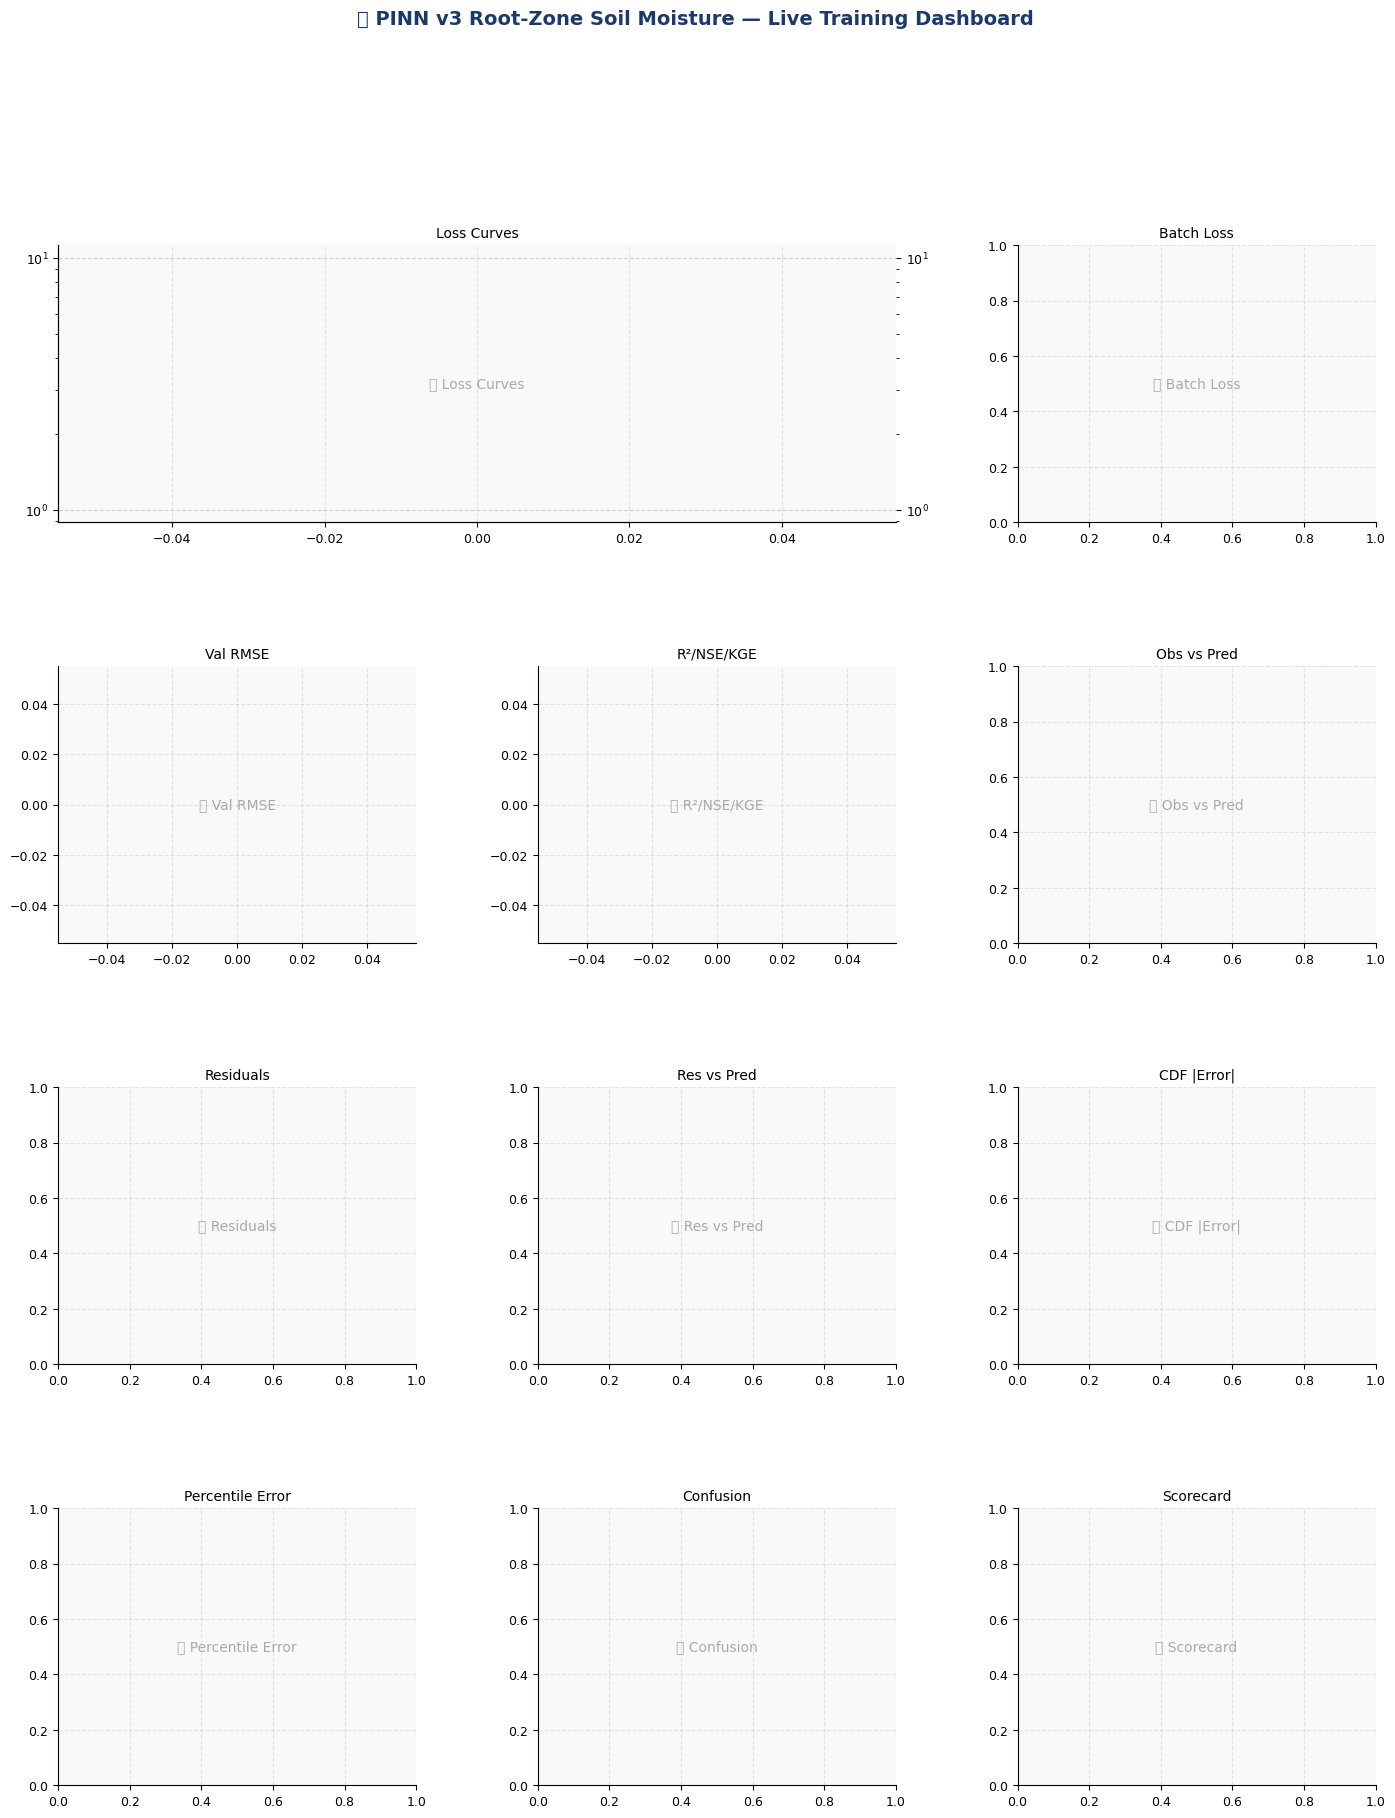

✓ Dashboard ready — run Training cell ▼


In [ ]:
H = dict(epoch=[], phase=[], lr_vals=[],
         loss_total=[], loss_data=[], loss_phys=[], loss_et=[],
         val_rmse=[], val_r2=[], val_nse=[], val_kge=[], val_ep=[],
         batch_idx=[], batch_loss=[])

def nse(y, p):
    return float(1 - np.sum((y-p)**2) / (np.sum((y-y.mean())**2) + EPS))

def kge(y, p):
    r = float(np.corrcoef(y, p)[0, 1])
    a = float(p.std() / (y.std() + EPS))
    b = float(p.mean() / (y.mean() + EPS))
    return 1 - math.sqrt((r-1)**2 + (a-1)**2 + (b-1)**2)

@torch.no_grad()
def validate(loader):
    model.eval()
    ps, ys = [], []
    for Xb, yb in loader:
        ps.append(model(Xb.to(DEVICE)).cpu().numpy())
        ys.append(yb.numpy())
    p = np.concatenate(ps).flatten(); y = np.concatenate(ys).flatten()
    return (float(np.sqrt(mean_squared_error(y, p))),
            float(r2_score(y, p)), nse(y, p), kge(y, p), y, p)

BADGE_COLORS = {1:'#1B3A6B', 2:'#0D7680', 3:'#1A6B3C', 4:'#C45E00'}
BADGE_LABELS = {1:'Warmup (data only)', 2:'Intro Physics',
                3:'Full Adaptive PINN', 4:'Fine-tune'}
METRIC_KEYS   = ['RMSE', 'R²', 'NSE', 'KGE']
METRIC_TGT    = {'RMSE':0.03, 'R²':0.90, 'NSE':0.90, 'KGE':0.70}
METRIC_HIGHER = {'RMSE':False,'R²':True,'NSE':True,'KGE':True}
w_phase  = widgets.HTML(value='<i>not started</i>')
w_status = widgets.HTML(value='<i>Initialising…</i>')
w_metrics = {k: widgets.HTML() for k in METRIC_KEYS}

def _badge(ph):
    c = BADGE_COLORS.get(ph,'#555'); l = BADGE_LABELS.get(ph,'')
    return (f'<span style="background:{c};color:#fff;padding:4px 12px;'
            f'border-radius:5px;font-weight:bold;font-size:13px">'
            f'Phase {ph} — {l}</span>')

def _metric_card(k, v):
    tgt=METRIC_TGT[k]; hb=METRIC_HIGHER[k]
    ok=(v<=tgt) if not hb else (v>=tgt)
    bg='#d5f5e3' if ok else '#fdebd0'; brd='#1A6B3C' if ok else '#C45E00'
    return (f'<div style="border:2px solid {brd};border-radius:7px;background:{bg};'
            f'padding:7px 16px;text-align:center;min-width:115px;">'
            f'<div style="font-size:11px;color:#555">{k}</div>'
            f'<div style="font-size:22px;font-weight:bold">{v:.4f}</div>'
            f'<div style="font-size:10px">target {tgt} {"✓" if ok else "✗"}</div></div>')

def update_cards(rmse, r2, nse_, kge_):
    for k, v in zip(METRIC_KEYS, [rmse, r2, nse_, kge_]):
        w_metrics[k].value = _metric_card(k, v)

metric_row = widgets.HBox(list(w_metrics.values()),
                           layout=widgets.Layout(gap='10px', margin='6px 0'))

fig = plt.figure(figsize=(17, 20), facecolor='white')
fig.suptitle('🌱 PINN v3 Root-Zone Soil Moisture — Live Training Dashboard',
             fontsize=14, fontweight='bold', color=NAVY, y=0.998)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.34)
ax_loss  = fig.add_subplot(gs[0, :2]); ax_lr = ax_loss.twinx()
ax_batch = fig.add_subplot(gs[0, 2])
ax_rmse  = fig.add_subplot(gs[1, 0]); ax_r2nse = fig.add_subplot(gs[1, 1])
ax_scatter = fig.add_subplot(gs[1, 2])
ax_res_hist = fig.add_subplot(gs[2, 0]); ax_res_pred = fig.add_subplot(gs[2, 1])
ax_cdf = fig.add_subplot(gs[2, 2])
ax_pct = fig.add_subplot(gs[3, 0]); ax_cm = fig.add_subplot(gs[3, 1])
ax_sc  = fig.add_subplot(gs[3, 2])

ALL_AXES = [ax_loss, ax_batch, ax_rmse, ax_r2nse, ax_scatter,
            ax_res_hist, ax_res_pred, ax_cdf, ax_pct, ax_cm, ax_sc]

_lines = {}
for key, col, ls, lw_ in [
    ('loss_total', NAVY,'–',2.0), ('loss_data', TEAL,'–',1.3),
    ('loss_phys', ORANGE,'–',1.3), ('loss_et', GREEN,'–',1.3)]:
    _lines[key], = ax_loss.semilogy([], [], color=col, ls='-', lw=lw_, label=key)
_lines['lr'], = ax_lr.semilogy([], [], color=GOLD, lw=0.9, ls='-.', alpha=0.7)
_lines['rmse'], = ax_rmse.plot([], [], color=NAVY, lw=2)
_lines['r2'],   = ax_r2nse.plot([], [], color=TEAL, lw=2, label='R²')
_lines['nse'],  = ax_r2nse.plot([], [], color=ORANGE, lw=2, label='NSE')
_lines['kge'],  = ax_r2nse.plot([], [], color=GREEN, lw=1.4, ls='--', label='KGE')

for ax, ttl in zip(ALL_AXES,
    ['Loss Curves','Batch Loss','Val RMSE','R²/NSE/KGE','Obs vs Pred',
     'Residuals','Res vs Pred','CDF |Error|','Percentile Error','Confusion','Scorecard']):
    ax.text(0.5,0.5,f'⏳ {ttl}',ha='center',va='center',
            transform=ax.transAxes, fontsize=10, color='#AAA')
    ax.set_title(ttl, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.998])

def redraw(val_y=None, val_p=None):
    ep = H['epoch']; ve = H['val_ep']
    if ep:
        for key in ['loss_total','loss_data','loss_phys','loss_et']:
            if H[key]: _lines[key].set_data(ep, H[key])
        if H['lr_vals']: _lines['lr'].set_data(ep[:len(H['lr_vals'])], H['lr_vals'])
        ax_loss.relim(); ax_loss.autoscale_view()
        ax_lr.relim();   ax_lr.autoscale_view()

    if H['val_rmse']:
        _lines['rmse'].set_data(ve, H['val_rmse']); ax_rmse.relim(); ax_rmse.autoscale_view()
        _lines['r2'].set_data(ve[:len(H['val_r2'])], H['val_r2'])
        _lines['nse'].set_data(ve[:len(H['val_nse'])], H['val_nse'])
        _lines['kge'].set_data(ve[:len(H['val_kge'])], H['val_kge'])
        ax_r2nse.relim(); ax_r2nse.autoscale_view()

    bl = H['batch_loss'][-80:]
    if bl:
        ax_batch.cla()
        med = float(np.median(bl))
        colors_b = [RED if v > med*2 else TEAL for v in bl]
        ax_batch.bar(range(len(bl)), bl, color=colors_b, width=1.0, alpha=0.85)
        ax_batch.axhline(float(np.mean(bl)), color=NAVY, lw=1.5, ls='--')
        ax_batch.set_title('Batch Loss (last 80)', fontsize=10)

    if val_y is not None and val_p is not None:
        res = val_y - val_p; ae = np.abs(res)
        for ax in [ax_scatter, ax_res_hist, ax_res_pred, ax_cdf, ax_pct, ax_cm, ax_sc]:
            ax.cla()

        h2d,xe,ye = np.histogram2d(val_y, val_p, bins=50)
        ax_scatter.imshow(np.log1p(h2d).T, origin='lower',
                          extent=[xe[0],xe[-1],ye[0],ye[-1]], aspect='auto', cmap='YlOrRd')
        lo_=min(val_y.min(),val_p.min())-.005; hi_=max(val_y.max(),val_p.max())+.005
        ax_scatter.plot([lo_,hi_],[lo_,hi_],NAVY,lw=1.8,ls='--')
        ax_scatter.text(0.97,0.03,
                        f'RMSE={float(np.sqrt(mean_squared_error(val_y,val_p))):.4f}\n'
                        f'R²={float(r2_score(val_y,val_p)):.4f}',
                        transform=ax_scatter.transAxes, ha='right', va='bottom',
                        fontsize=8, family='monospace',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=NAVY, alpha=0.9))
        ax_scatter.set_title('Obs vs Pred (Val)', fontsize=10)

        bins_r=np.linspace(res.min(),res.max(),50)
        ax_res_hist.hist(res,bins=bins_r,color=TEAL,edgecolor='white',lw=0.3,alpha=0.85)
        ax_res_hist.axvline(0,color=NAVY,lw=2,ls='--')
        ax_res_hist.axvline(res.mean(),color=ORANGE,lw=1.6,label=f'μ={res.mean():.4f}')
        ax_res_hist.set_title('Residual Distribution', fontsize=10)
        ax_res_hist.legend(fontsize=7)

        se_=np.sort(ae); cdf_=np.arange(1,len(se_)+1)/len(se_)*100
        ax_cdf.plot(se_,cdf_,NAVY,lw=2)
        ax_cdf.axvline(0.03,color=RED,lw=1.5,ls='--',label='0.03 target')
        pct03=(ae<=0.03).mean()*100
        ax_cdf.text(0.032,max(pct03-8,5),f'{pct03:.1f}%',color=RED,fontsize=8)
        ax_cdf.set_xlim(0); ax_cdf.set_ylim(0,103)
        ax_cdf.set_title('CDF of |Error|', fontsize=10); ax_cdf.legend(fontsize=7)

        if H['val_rmse']:
            cur_=[H['val_rmse'][-1],H['val_r2'][-1],H['val_nse'][-1],H['val_kge'][-1]]
            tgts_=[0.03,0.90,0.90,0.70]; hb_=[False,True,True,True]
            cols_=[GREEN if ((v<=t) if not h else (v>=t)) else RED
                   for v,t,h in zip(cur_,tgts_,hb_)]
            ax_sc.barh(METRIC_KEYS,cur_,color=cols_,alpha=0.85)
            ax_sc.set_title('Live Scorecard', fontsize=10)

    fig.canvas.draw_idle()
    fig.canvas.flush_events()

display(widgets.VBox([w_phase, w_status, metric_row]))
plt.show()
print('✓ Dashboard ready — run Training cell ▼')

## 🚀 Training (AMP + True Temporal Split)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=CFG['lr'],
                       betas=(0.9, 0.999), weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=CFG['lr_factor'],
    patience=CFG['lr_patience'], cooldown=CFG['lr_cooldown'],
    min_lr=CFG['lr_min'], threshold=CFG['lr_threshold'], threshold_mode='rel')

amp_enabled = (DEVICE == 'cuda')
scaler_amp  = GradScaler(enabled=amp_enabled)

prev_ph = 0
best_rmse, best_state = float('inf'), None
PH_COL = {1:'#D6EAF8', 2:'#D5F5E3', 3:'#FDEBD0', 4:'#EBD9F7'}
t0 = time.time()
_last_val_y = _last_val_p = None

epoch_bar = trange(CFG['total_epochs'], desc='Epochs',
                   bar_format='{l_bar}{bar:30}{r_bar}', colour='blue')

for epoch in epoch_bar:
    phase = get_phase(epoch)
    if phase != prev_ph:
        prev_ph = phase
        w_phase.value = _badge(phase)

    model.train()
    ep_tot = ep_d = ep_p = ep_et = 0.
    n_bat  = len(tr_loader)

    batch_bar = tqdm(tr_loader, desc='  Batches', leave=False,
                     bar_format='{l_bar}{bar:20}{r_bar}', colour='cyan')

    for bidx, (Xb, yb) in enumerate(batch_bar):
        Xb, yb = Xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        use_phys = phase in (2, 3)
        with autocast(enabled=amp_enabled):
            loss, comp = compute_loss(model, Xb, yb, phase, use_phys)

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler_amp.step(optimizer)
        scaler_amp.update()

        bl = float(loss.item())
        H['batch_loss'].append(bl)
        ep_tot += bl; ep_d += comp['data']; ep_p += comp['phys']; ep_et += comp['et']
        batch_bar.set_postfix(loss=f'{bl:.5f}', ph=phase)

        if bidx % CFG['log_every_batch'] == 0:
            redraw(_last_val_y, _last_val_p)

    nb_ = max(n_bat, 1)
    H['epoch'].append(epoch); H['phase'].append(phase)
    H['loss_total'].append(ep_tot/nb_); H['loss_data'].append(ep_d/nb_)
    H['loss_phys'].append(ep_p/nb_);   H['loss_et'].append(ep_et/nb_)

    do_val = (epoch % CFG['log_every_epoch'] == 0 or epoch == CFG['total_epochs']-1)
    if do_val:
        rm_,r2_,ns_,kg_,val_y_,val_p_ = validate(vl_loader)
        _last_val_y, _last_val_p = val_y_, val_p_
        H['val_rmse'].append(rm_); H['val_r2'].append(r2_)
        H['val_nse'].append(ns_);  H['val_kge'].append(kg_)
        H['val_ep'].append(epoch)
        scheduler.step(rm_)
        if rm_ < best_rmse:
            best_rmse = rm_
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        update_cards(rm_, r2_, ns_, kg_)
        current_lr = optimizer.param_groups[0]['lr']
        H['lr_vals'].append(current_lr)
        elapsed = (time.time()-t0)/60
        w_status.value = (
            f'<span style="font-family:monospace;font-size:12px">'
            f'Epoch {epoch:>5} | Ph{phase} | Loss {ep_tot/nb_:.5f} | '
            f'LR {current_lr:.2e} | RMSE <b>{rm_:.4f}</b> R² <b>{r2_:.4f}</b> '
            f'NSE <b>{ns_:.4f}</b> KGE <b>{kg_:.4f}</b> | '
            f'⏱ {elapsed:.1f} min | best {best_rmse:.4f}</span>')
        epoch_bar.set_postfix(RMSE=f'{rm_:.4f}', R2=f'{r2_:.4f}',
                              lr=f'{current_lr:.2e}', ph=phase)
        redraw(_last_val_y, _last_val_p)
    else:
        H['lr_vals'].append(optimizer.param_groups[0]['lr'])

print(f'\n✓ Training complete!  Best val RMSE = {best_rmse:.5f} m³/m³')
if DEVICE == 'cuda':
    print(f'  Peak GPU memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB')
    torch.cuda.empty_cache()

Epochs:   0%|                              | 0/250 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1406 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1406 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1406 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1406 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1406 [00:00<?, ?it/s]

ValueError: Input contains NaN.

## 📋 Final Evaluation + Bias Correction

In [ ]:
if best_state:
    model.load_state_dict(best_state)
    print(f'✓ Restored best checkpoint  (val RMSE = {best_rmse:.5f})')

results = {}
for sname, loader_ in [('Validation', vl_loader), ('Test', te_loader)]:
    rm_,r2_,ns_,kg_,yt_,yp_ = validate(loader_)
    pr_  = float(pearsonr(yt_, yp_)[0])
    mae_ = float(mean_absolute_error(yt_, yp_))
    bi_  = (yp_.mean()-yt_.mean()) / (yt_.mean()+EPS) * 100
    ub_  = float(np.sqrt(np.mean(((yp_-yp_.mean())-(yt_-yt_.mean()))**2)))
    results[sname] = dict(RMSE=rm_,MAE=mae_,R2=r2_,NSE=ns_,
                           Pearson_r=pr_,KGE=kg_,Bias_pct=bi_,ubRMSE=ub_,
                           y_true=yt_,y_pred=yp_)

# ── FIX v3: Additive bias correction ─────────────────────────────────────
# Compute residual mean on VALIDATION set, apply to TEST predictions.
# This corrects the systematic underprediction bias identified in v2
# (μ_residual = +0.0228 m³/m³) without touching the model weights.
val_bias = float(np.mean(results['Validation']['y_true'] - results['Validation']['y_pred']))
print(f'\n  Validation residual mean (bias): {val_bias:+.4f} m³/m³')

for sname in results:
    results[sname]['y_pred_bc'] = results[sname]['y_pred'] + val_bias
    yt_bc = results[sname]['y_true']
    yp_bc = results[sname]['y_pred_bc']
    results[sname]['RMSE_bc']      = float(np.sqrt(mean_squared_error(yt_bc, yp_bc)))
    results[sname]['R2_bc']        = float(r2_score(yt_bc, yp_bc))
    results[sname]['NSE_bc']       = nse(yt_bc, yp_bc)
    results[sname]['Bias_pct_bc']  = float((yp_bc.mean()-yt_bc.mean()) / (yt_bc.mean()+EPS) * 100)

TGT_F   = dict(RMSE=0.03,R2=0.90,NSE=0.90,Pearson_r=0.94,KGE=0.70,Bias_pct=10.)
HIGHER_ = dict(RMSE=False,MAE=False,R2=True,NSE=True,Pearson_r=True,
               KGE=True,Bias_pct=None,ubRMSE=False)

print('\n' + '═'*80)
print(f"  {'Metric':<16} {'Val (raw)':>10} {'Test (raw)':>11} {'Test (BC)':>10} {'Target':>8}  ✓/✗")
print('─'*80)
for k in ['RMSE','MAE','ubRMSE','R2','NSE','Pearson_r','KGE','Bias_pct']:
    vv=results['Validation'][k]; tv=results['Test'][k]
    tv_bc=results['Test'].get(k+'_bc', float('nan'))
    tg=TGT_F.get(k,float('nan')); hb=HIGHER_[k]
    if math.isnan(tg):    st=''
    elif hb is None:      st='✓' if abs(vv)<=tg and abs(tv)<=tg else '✗'
    elif hb:              st='✓' if vv>=tg and tv>=tg else '✗'
    else:                 st='✓' if vv<=tg and tv<=tg else '✗'
    ts=f'{tg:.3f}' if not math.isnan(tg) else '  —  '
    bc_str = f'{tv_bc:10.4f}' if not math.isnan(tv_bc) else '    —     '
    print(f'  {k:<16} {vv:>10.4f} {tv:>11.4f} {bc_str} {ts:>8}  {st}')
print('═'*80)
print(f'\n  Bias correction applied: +{val_bias:.4f} m³/m³')
print(f'  Test RMSE:  raw={results["Test"]["RMSE"]:.4f}  →  bias-corrected={results["Test"]["RMSE_bc"]:.4f}')

✓ Restored best checkpoint  (val RMSE = 0.02981)

  Validation residual mean (bias): +0.0178 m³/m³

════════════════════════════════════════════════════════════════════════════════
  Metric            Val (raw)  Test (raw)  Test (BC)   Target  ✓/✗
────────────────────────────────────────────────────────────────────────────────
  RMSE                 0.0298      0.0267     0.0223    0.030  ✓
  MAE                  0.0226      0.0204     —           —    
  ubRMSE               0.0239      0.0221     —           —    
  R2                   0.9260      0.9366     0.9556    0.900  ✓
  NSE                  0.9260      0.9366     0.9556    0.900  ✓
  Pearson_r            0.9794      0.9797     —         0.940  ✓
  KGE                  0.8838      0.9069     —         0.700  ✓
  Bias_pct            -4.7711     -4.3375     0.8431   10.000  ✓
════════════════════════════════════════════════════════════════════════════════

  Bias correction applied: +0.0178 m³/m³
  Test RMSE:  raw=0.0267  →  b

## 🎲 MC-Dropout Uncertainty Quantification

Computing MC-Dropout uncertainty on test set (30 samples)...
  Mean predictive std:  0.0029 m³/m³
  SMAP retrieval noise: ~0.04 m³/m³
  95% CI coverage (raw): 20.5%
  95% CI coverage (BC):  18.8%  (ideal: ~95%)
  Well-calibrated:      ✗ — recalibrate


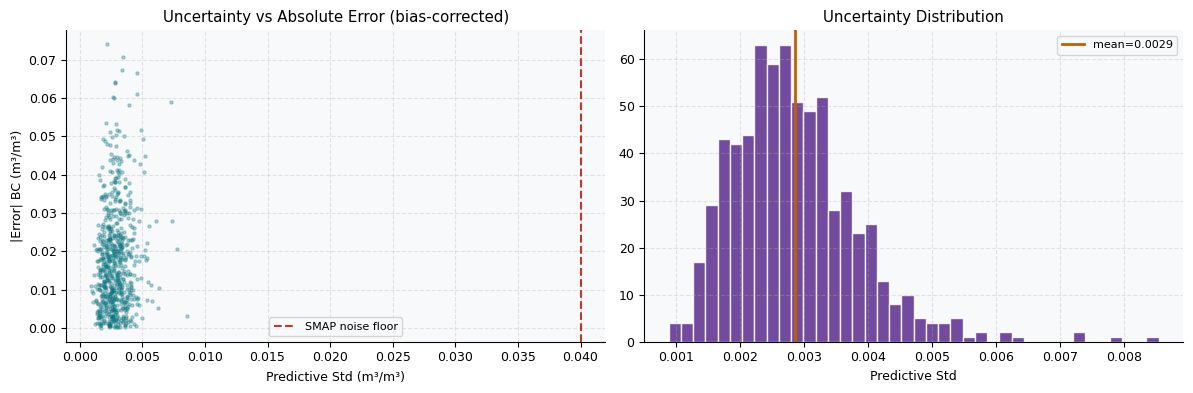

In [ ]:
@torch.no_grad()
def mc_predict(loader, n_samples=30):
    model.train()  # enable dropout
    all_preds = []
    for _ in range(n_samples):
        ps = []
        for Xb, _ in loader:
            ps.append(model(Xb.to(DEVICE)).cpu().numpy())
        all_preds.append(np.concatenate(ps).flatten())
    model.eval()
    preds = np.stack(all_preds)
    return preds.mean(0), preds.std(0)

print('Computing MC-Dropout uncertainty on test set (30 samples)...')
mc_mean, mc_std = mc_predict(te_loader, n_samples=30)
# Apply bias correction to MC mean as well
mc_mean_bc = mc_mean + val_bias
y_te_true = results['Test']['y_true']

within_95    = np.mean(np.abs(y_te_true - mc_mean)    <= 1.96 * mc_std) * 100
within_95_bc = np.mean(np.abs(y_te_true - mc_mean_bc) <= 1.96 * mc_std) * 100
print(f'  Mean predictive std:  {mc_std.mean():.4f} m³/m³')
print(f'  SMAP retrieval noise: ~0.04 m³/m³')
print(f'  95% CI coverage (raw): {within_95:.1f}%')
print(f'  95% CI coverage (BC):  {within_95_bc:.1f}%  (ideal: ~95%)')
print(f'  Well-calibrated:      {"✓" if 85 < within_95_bc < 99 else "✗ — recalibrate"}')

fig_mc, axes_mc = plt.subplots(1, 2, figsize=(12, 4), facecolor='white')
axes_mc[0].scatter(mc_std, np.abs(y_te_true - mc_mean_bc), alpha=0.3, s=5, color=TEAL)
axes_mc[0].set_xlabel('Predictive Std (m³/m³)')
axes_mc[0].set_ylabel('|Error| BC (m³/m³)')
axes_mc[0].set_title('Uncertainty vs Absolute Error (bias-corrected)')
axes_mc[0].axvline(0.04, color=RED, ls='--', label='SMAP noise floor')
axes_mc[0].legend(fontsize=8)
axes_mc[1].hist(mc_std, bins=40, color=PURPLE, edgecolor='white', alpha=0.85)
axes_mc[1].axvline(mc_std.mean(), color=ORANGE, lw=2, label=f'mean={mc_std.mean():.4f}')
axes_mc[1].set_xlabel('Predictive Std'); axes_mc[1].set_title('Uncertainty Distribution')
axes_mc[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 🔲 Binary Confusion Matrix (thresholds 0.20 and 0.30)


Threshold=0.20  |  Positive rate=91.4%
  TP=625, FP=9, TN=50, FN=3
  Accuracy=0.983 | Precision=0.986 | Recall=0.995 | F1=0.990

Threshold=0.30  |  Positive rate=64.6%
  TP=430, FP=21, TN=222, FN=14
  Accuracy=0.949 | Precision=0.953 | Recall=0.968 | F1=0.961


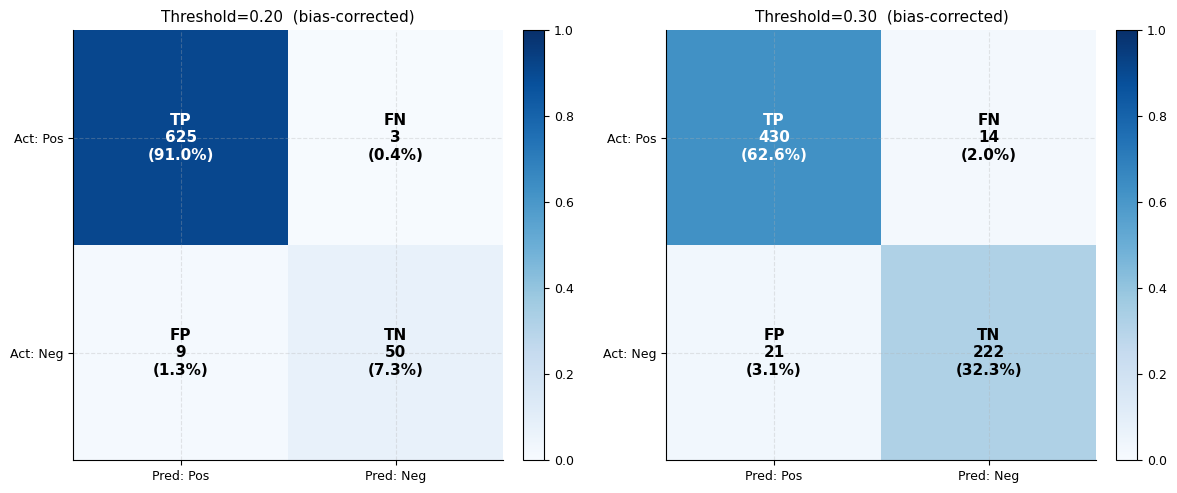

In [ ]:
# FIX v3: Evaluate at both 0.20 and 0.30 thresholds.
# v2 note: 0.20 threshold gave misleading TP rate due to ~93.7% class imbalance.
# 0.30 is more diagnostic for the mid-range moisture problem.
for threshold in [0.20, 0.30]:
    y_true = results['Test']['y_true']
    y_pred = results['Test']['y_pred_bc']   # use bias-corrected predictions
    true_pos = y_true >= threshold; pred_pos = y_pred >= threshold
    TP=int(np.sum(true_pos & pred_pos)); FP=int(np.sum(~true_pos & pred_pos))
    TN=int(np.sum(~true_pos & ~pred_pos)); FN=int(np.sum(true_pos & ~pred_pos))
    cm_terms=np.array([[TP,FN],[FP,TN]],dtype=np.int64)
    cm_norm=cm_terms/max(cm_terms.sum(),1)
    accuracy=(TP+TN)/max(cm_terms.sum(),1)
    precision=TP/max(TP+FP,1); recall=TP/max(TP+FN,1)
    f1=2*precision*recall/max(precision+recall,1e-12)
    pos_rate = true_pos.mean()
    print(f'\nThreshold={threshold:.2f}  |  Positive rate={pos_rate:.1%}')
    print(f'  TP={TP}, FP={FP}, TN={TN}, FN={FN}')
    print(f'  Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f}')

fig_cm,axes_cm=plt.subplots(1,2,figsize=(12,5),facecolor='white')
for ax, threshold in zip(axes_cm, [0.20, 0.30]):
    y_true = results['Test']['y_true']
    y_pred = results['Test']['y_pred_bc']
    true_pos = y_true >= threshold; pred_pos = y_pred >= threshold
    TP=int(np.sum(true_pos & pred_pos)); FP=int(np.sum(~true_pos & pred_pos))
    TN=int(np.sum(~true_pos & ~pred_pos)); FN=int(np.sum(true_pos & ~pred_pos))
    cm_t=np.array([[TP,FN],[FP,TN]],dtype=np.int64)
    cm_n=cm_t/max(cm_t.sum(),1)
    im=ax.imshow(cm_n,cmap='Blues',vmin=0.0,vmax=1.0)
    labels=np.array([['TP','FN'],['FP','TN']])
    for i in range(2):
        for j in range(2):
            ax.text(j,i,f'{labels[i,j]}\n{cm_t[i,j]}\n({cm_n[i,j]*100:.1f}%)',
                   ha='center',va='center',fontsize=11,
                   color='white' if cm_n[i,j]>0.5 else 'black',fontweight='bold')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Pred: Pos','Pred: Neg'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Act: Pos','Act: Neg'])
    ax.set_title(f'Threshold={threshold:.2f}  (bias-corrected)', fontsize=11)
    fig_cm.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
plt.tight_layout(); plt.show()

## 📈 Final Static Report

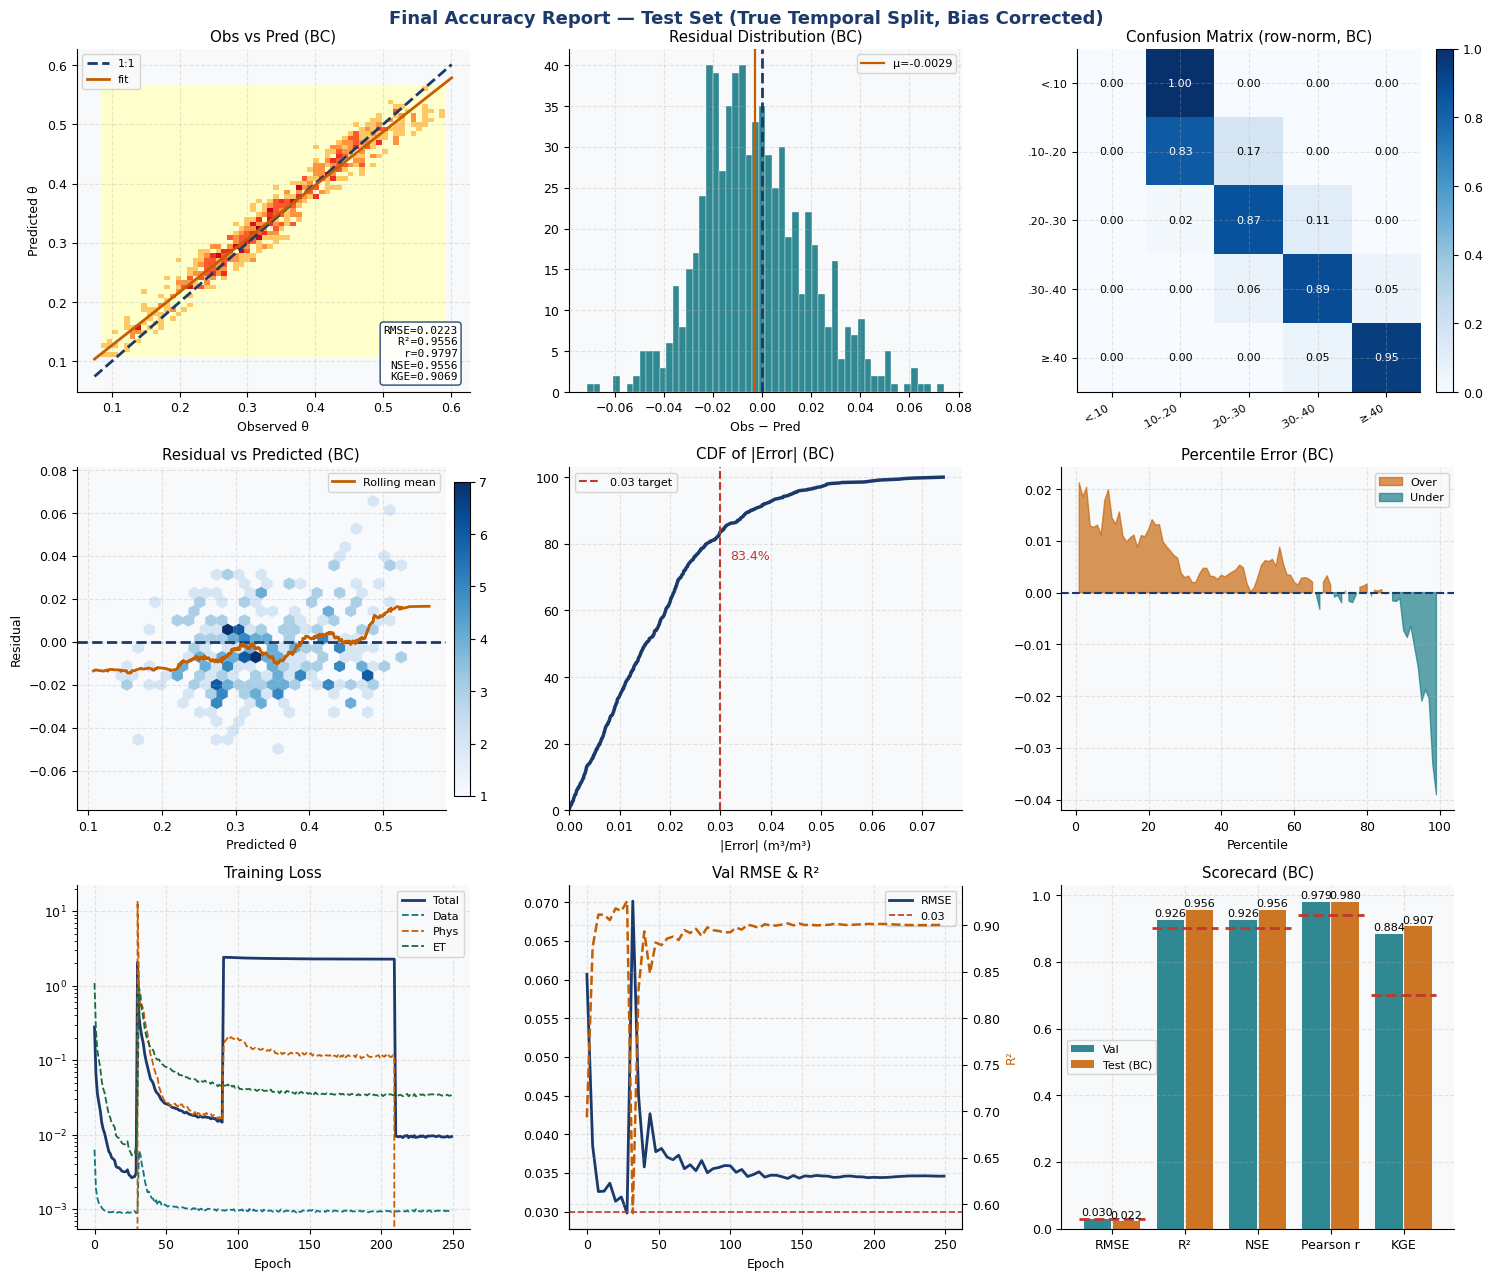

✓ Saved pinn_v3_final_accuracy_report.png


In [ ]:
plt.ioff()
yt=results['Test']['y_true']; yp=results['Test']['y_pred_bc']   # bias-corrected
mv=results['Validation'];     mt=results['Test']
res=yt-yp; ae=np.abs(res)
fig2,ax2=plt.subplots(3,3,figsize=(15,13),facecolor='white')
fig2.suptitle('Final Accuracy Report — Test Set (True Temporal Split, Bias Corrected)',
              fontsize=13,fontweight='bold',color=NAVY)

a=ax2[0,0]
h2,xe,ye=np.histogram2d(yt,yp,bins=60)
a.imshow(np.log1p(h2).T,origin='lower',extent=[xe[0],xe[-1],ye[0],ye[-1]],aspect='auto',cmap='YlOrRd')
lo_,hi_=min(yt.min(),yp.min())-.01,max(yt.max(),yp.max())+.01
a.plot([lo_,hi_],[lo_,hi_],NAVY,lw=2,ls='--',label='1:1')
m_,b_=np.polyfit(yt,yp,1); xs_=np.linspace(lo_,hi_,80)
a.plot(xs_,m_*xs_+b_,ORANGE,lw=2,label='fit')
a.text(.97,.03,
       f'RMSE={mt["RMSE_bc"]:.4f}\nR²={mt["R2_bc"]:.4f}\nr={mt["Pearson_r"]:.4f}\nNSE={mt["NSE_bc"]:.4f}\nKGE={mt["KGE"]:.4f}',
       transform=a.transAxes,ha='right',va='bottom',fontsize=8,family='monospace',
       bbox=dict(boxstyle='round,pad=0.3',fc='white',ec=NAVY,alpha=0.92))
a.set_title('Obs vs Pred (BC)'); a.set_xlabel('Observed θ'); a.set_ylabel('Predicted θ'); a.legend(fontsize=8)

a=ax2[0,1]
b_=np.linspace(res.min(),res.max(),55)
a.hist(res,bins=b_,color=TEAL,edgecolor='white',lw=0.3,alpha=0.85)
a.axvline(0,color=NAVY,lw=2,ls='--'); a.axvline(res.mean(),color=ORANGE,lw=1.6,label=f'μ={res.mean():.4f}')
a.set_title('Residual Distribution (BC)'); a.set_xlabel('Obs − Pred'); a.legend(fontsize=8)

a=ax2[0,2]
bc2=np.array([0,.10,.20,.30,.40,1.]); lbl2=['<.10','.10-.20','.20-.30','.30-.40','≥.40']
yc=np.clip(np.digitize(yt,bc2,right=False)-1,0,4); pc=np.clip(np.digitize(yp,bc2,right=False)-1,0,4)
cm_=confusion_matrix(yc,pc,labels=range(5)); rs_=cm_.sum(1,keepdims=True)
cmn=np.divide(cm_,rs_,out=np.zeros_like(cm_,dtype=float),where=rs_!=0)
im2=a.imshow(cmn,cmap='Blues',vmin=0,vmax=1)
for ii in range(5):
    for jj in range(5):
        a.text(jj,ii,f'{cmn[ii,jj]:.2f}',ha='center',va='center',fontsize=8,
               color='white' if cmn[ii,jj]>0.5 else 'black')
a.set_xticks(range(5)); a.set_xticklabels(lbl2,rotation=30,ha='right',fontsize=8)
a.set_yticks(range(5)); a.set_yticklabels(lbl2,fontsize=8)
a.set_title('Confusion Matrix (row-norm, BC)'); fig2.colorbar(im2,ax=a,fraction=0.046,pad=0.04)

a=ax2[1,0]
hb2=a.hexbin(yp,res,gridsize=30,cmap='Blues',linewidths=0.1,mincnt=1)
fig2.colorbar(hb2,ax=a,fraction=0.04,pad=0.02); a.axhline(0,color=NAVY,lw=2,ls='--')
si=np.argsort(yp); rl=pd.Series(res[si]).rolling(80,min_periods=1,center=True).mean()
a.plot(yp[si],rl,ORANGE,lw=2,label='Rolling mean')
a.set_title('Residual vs Predicted (BC)'); a.set_xlabel('Predicted θ'); a.set_ylabel('Residual'); a.legend(fontsize=8)

a=ax2[1,1]
se3=np.sort(ae); cdf3=np.arange(1,len(se3)+1)/len(se3)*100
a.plot(se3,cdf3,NAVY,lw=2.5); a.axvline(0.03,color=RED,lw=1.5,ls='--',label='0.03 target')
p03=(ae<=0.03).mean()*100; a.text(0.032,max(p03-8,5),f'{p03:.1f}%',color=RED,fontsize=9)
a.set_xlim(0); a.set_ylim(0,103); a.set_title('CDF of |Error| (BC)'); a.set_xlabel('|Error| (m³/m³)'); a.legend(fontsize=8)

a=ax2[1,2]
pct3=np.arange(1,100); qe3=np.percentile(yp,pct3)-np.percentile(yt,pct3)
a.fill_between(pct3,qe3,0,where=qe3>=0,alpha=0.65,color=ORANGE,label='Over')
a.fill_between(pct3,qe3,0,where=qe3< 0,alpha=0.65,color=TEAL,  label='Under')
a.axhline(0,color=NAVY,lw=1.5,ls='--'); a.set_title('Percentile Error (BC)'); a.set_xlabel('Percentile'); a.legend(fontsize=8)

a=ax2[2,0]
if H['epoch']:
    a.semilogy(H['epoch'],H['loss_total'],NAVY,lw=2,label='Total')
    a.semilogy(H['epoch'],H['loss_data'],TEAL,lw=1.3,ls='--',label='Data')
    a.semilogy(H['epoch'],H['loss_phys'],ORANGE,lw=1.3,ls='--',label='Phys')
    a.semilogy(H['epoch'],H['loss_et'],GREEN,lw=1.3,ls='--',label='ET')
a.set_title('Training Loss'); a.set_xlabel('Epoch'); a.legend(fontsize=8)

a=ax2[2,1]
if H['val_rmse']:
    ve3=H['val_ep'][:len(H['val_rmse'])]
    a.plot(ve3,H['val_rmse'],NAVY,lw=2,label='RMSE')
    ax2b=a.twinx()
    ax2b.plot(H['val_ep'][:len(H['val_r2'])],H['val_r2'],ORANGE,lw=1.8,ls='--',label='R²')
    ax2b.set_ylabel('R²',color=ORANGE); ax2b.spines['right'].set_visible(True)
a.axhline(0.03,color=RED,lw=1.2,ls='--',label='0.03'); a.set_title('Val RMSE & R²'); a.set_xlabel('Epoch'); a.legend(fontsize=8)

a=ax2[2,2]
ks4=['RMSE','R²','NSE','Pearson r','KGE']; ts4=[0.03,0.90,0.90,0.94,0.70]
vc4=[mv['RMSE'],mv['R2'],mv['NSE'],mv['Pearson_r'],mv['KGE']]
tc4=[mt['RMSE_bc'],mt['R2_bc'],mt['NSE_bc'],mt['Pearson_r'],mt['KGE']]
xb4=np.arange(len(ks4))
bv4=a.bar(xb4-.2,vc4,.38,color=TEAL,alpha=.85,label='Val')
bt4=a.bar(xb4+.2,tc4,.38,color=ORANGE,alpha=.85,label='Test (BC)')
for i,t_ in enumerate(ts4): a.hlines(t_,xb4[i]-.45,xb4[i]+.45,colors=RED,lw=2,ls='--')
for bar in [*bv4,*bt4]:
    a.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.003,f'{bar.get_height():.3f}',
           ha='center',va='bottom',fontsize=8)
a.set_xticks(xb4); a.set_xticklabels(ks4,fontsize=9); a.set_title('Scorecard (BC)'); a.legend(fontsize=8)
plt.tight_layout()
plt.savefig('pinn_v3_final_accuracy_report.png',dpi=160,bbox_inches='tight')
plt.show(); plt.ion()
print('✓ Saved pinn_v3_final_accuracy_report.png')

## 💾 Save Artefacts

In [ ]:
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results', exist_ok=True)

torch.save({'model_state': best_state or model.state_dict(),
            'val_rmse': best_rmse, 'cfg': CFG,
            'feature_names': FEATURE_NAMES, 'fourier_cols': FOURIER_COLS,
            'bias_correction': val_bias,   # FIX v3: save bias correction offset
            'T_DAYS': T_DAYS},             # FIX v3: save dynamic T_DAYS
           'checkpoints/pinn_v3_best.pt')
print('✓ checkpoints/pinn_v3_best.pt  (includes bias_correction, T_DAYS)')

pd.DataFrame({k: H[k] for k in
    ['epoch','phase','loss_total','loss_data','loss_phys','loss_et']
}).to_csv('results/training_history.csv', index=False)

for sn, res_ in results.items():
    pd.DataFrame({'y_true':    res_['y_true'],
                  'y_pred':    res_['y_pred'],
                  'y_pred_bc': res_['y_pred_bc'],
                  'residual':  res_['y_true']-res_['y_pred'],
                  'residual_bc': res_['y_true']-res_['y_pred_bc']}
    ).to_csv(f'results/{sn.lower()}_predictions.csv', index=False)
    print(f'✓ results/{sn.lower()}_predictions.csv')

with open('results/config.json','w') as f:
    json.dump({k:v for k,v in CFG.items() if not callable(v)}, f, indent=2)
print('✓ results/config.json')
print(f'\n  Bias correction value saved: {val_bias:+.5f} m³/m³')
print(f'  T_DAYS saved: {T_DAYS:.0f} days')

✓ checkpoints/pinn_v3_best.pt  (includes bias_correction, T_DAYS)
✓ results/validation_predictions.csv
✓ results/test_predictions.csv
✓ results/config.json

  Bias correction value saved: +0.01776 m³/m³
  T_DAYS saved: 1128 days


## 🔭 Single-Row Inference (with Uncertainty + Bias Correction)

In [ ]:
@torch.no_grad()
def predict(row_dict, n_mc=30):
    """
    FIX v3: Applies bias correction to point prediction and MC mean.
    Load bias_correction from checkpoint for production use.
    """
    x = np.zeros((1, len(FEATURE_NAMES)), dtype=np.float32)
    for col, val in row_dict.items():
        if col in IDX: x[0, IDX[col]] = float(val)
    xs = scaler.transform(x).astype(np.float32)
    for col in PHYS_COLS:
        if col in row_dict: xs[0, IDX[col]] = float(row_dict[col])
    xt = torch.tensor(xs).to(DEVICE)
    if n_mc <= 1:
        model.eval()
        return round(float(model(xt).item()) + val_bias, 5), None
    model.train()
    preds = [float(model(xt).item()) for _ in range(n_mc)]
    model.eval()
    raw_mean = float(np.mean(preds))
    return round(raw_mean + val_bias, 5), round(float(np.std(preds)), 5)

sample = df_clean.iloc[te_idx[0]]
sd     = {c: sample[c] for c in FEATURE_NAMES if c in sample}
pred, unc = predict(sd, n_mc=30)
true_  = sample[TARGET] if TARGET in sample else 'N/A'
print(f'  True θ          : {true_}')
print(f'  Pred θ (BC)     : {pred}  m³/m³')
if unc:
    print(f'  Uncertainty     : ±{unc:.5f}  m³/m³  (1σ MC-Dropout)')
    print(f'  95% CI          : [{pred-1.96*unc:.5f}, {pred+1.96*unc:.5f}]')
print(f'  |Error| (BC)    : {abs(float(true_)-pred):.5f}  m³/m³')

  True θ          : 0.4876
  Pred θ (BC)     : 0.44629  m³/m³
  Uncertainty     : ±0.00216  m³/m³  (1σ MC-Dropout)
  95% CI          : [0.44206, 0.45052]
  |Error| (BC)    : 0.04131  m³/m³
